In [3]:
from openai import AsyncOpenAI
from openai.types.shared.reasoning import Reasoning
from openai.types.responses.tool_param import CodeInterpreter
from openai.types.responses import ResponseTextDeltaEvent

from agents import (
    Agent, 
    Runner, 
    function_tool,
    ItemHelpers,
    ModelSettings, 
    WebSearchTool, 
    CodeInterpreterTool, 
    HostedMCPTool,
    FileSearchTool
)
from agents.extensions.visualization import draw_graph
from agents.mcp import MCPServerStreamableHttp


Quick connection test

In [2]:
client = AsyncOpenAI()
r = await client.responses.create(
    model='gpt-5.1',
    reasoning={'effort': 'none', 'summary': 'detailed'},
    instructions='You are a helpful, to-the-point AI that answers quickly and concisely',
    input=[{'role': 'user', 'content': 'What is the capital of France?'}],
)

print(r.usage)
print(r.output_text)

ResponseUsage(input_tokens=33, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=17, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=50)
Paris is the capital of France.


### Build your agent

Prompt

In [4]:
system_message = """

You are a capable AI assistant helping deal teams in the private equity sector. You have access to tools to conduct deal sourcing. our number one goal is to collect exhaustive information about the presented target company using access to related documents, the internet, external information sources (through MCP servers) and additional context enhancement tools you have access to.

Your task is to gather information - not to format it. You don't have to pay attention to formatting or style, you only exist to collect, gather, present information, that helps the company decide whether the target is an attractive investment opportunity and is worth going deeper, or should be dimissed. This decision is NOT up to you. You are NOT to give suggestion, advice. You are only to PRESENT unbiased, objective information.

"""

MCP config

In [5]:
MCP_server_config = {
    "type": "mcp",
    "server_label": "",
    "server_url": "",
    "require_approval": "never",
    #"headers": {
    #    'Authorization': f'Bearer {access_token}',
    #},
    #"allowed_tools": ["", ""]
}

In [16]:
agent = Agent(
    name="Deal Sourcing Agent",
    model='gpt-5.1',
    model_settings=ModelSettings(
        reasoning=Reasoning(
                effort='low',
                summary="detailed",
            )
    ),
    instructions=system_message,
    tools=[
        WebSearchTool(search_context_size='medium'),
        CodeInterpreterTool(
            tool_config=CodeInterpreter(
                container={
                        "type": "auto",
                        "file_ids": []
                    },
                    type='code_interpreter'
            )
        ),
        #FileSearchTool(
        #    max_num_results=5,
        #    vector_store_ids=["VECTOR_STORE_ID"],
        #    ranking_options={
        #        'hybrid_search': {
        #            'embedding_weight': 0.5,
        #            'text_weight': 0.5,
        #        },
        #        'ranker': 'auto',
        #    }
        #),
        #HostedMCPTool(tool_config=MCP_server_config)
    ],
)

In [7]:
async with MCPServerStreamableHttp(
    name="Stock Market Tools",
    params={
        "url": "http://localhost:8000/mcp/",  
        "timeout": 30
    },
    cache_tools_list=True,
) as stock_server:
    
    agent = Agent(
        name="Deal Sourcing Agent",
        model='gpt-5.1',
        model_settings=ModelSettings(
            reasoning=Reasoning(effort='low', summary="detailed")
        ),
        instructions=system_message,
        mcp_servers=[stock_server], 
        tools=[
            WebSearchTool(search_context_size='medium'),
            CodeInterpreterTool(
                tool_config=CodeInterpreter(
                    container={"type": "auto", "file_ids": []},
                    type='code_interpreter'
                )
            ),
        ],
    )

Let's take a look at it!

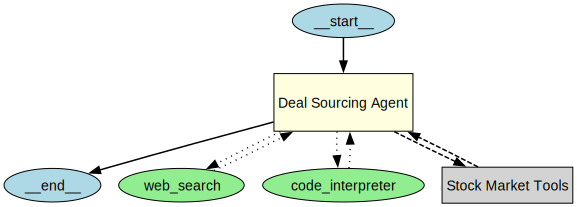

In [8]:
draw_graph(agent)

Run Agent

In [9]:
target_company = "Culver's - Wisconsin based burger chain"
user_message = f"""

Your target company is {target_company}.
Use the available tools to conduct your research. Present your findings in a memo-like writeup, organized into topics.

"""

In [10]:
async def stream_results(result):

    async for ev in result.stream_events():
        if ev.type == "agent_updated_stream_event":
            #print(f"\n--- switched to agent: {ev.new_agent.name} ---")
            #print(f"\n--- RESEARCHING ---")
            pass
        elif ev.type == "run_item_stream_event" and ev.name == "tool_called":
            # Print MCP tool calls when they start
            if ev.item.type == 'tool_call_item' and hasattr(ev.item, 'raw_item'):
                raw_item = ev.item.raw_item
                if hasattr(raw_item, 'type') and raw_item.type == 'mcp_call':
                    print(f"🛠️ [MCP {raw_item.name}] server={raw_item.server_label}")
                    print('===' * 20)
                    print('\n\n')
                # Print Code Interpreter tool calls when they start
                elif hasattr(raw_item, 'type') and raw_item.type == 'code_interpreter_call':
                    print(f"🐍 Code Interpreter Call")
                    if hasattr(raw_item, 'code') and raw_item.code:
                        print(f"🐍 Code:\n{raw_item.code}")
                    print('===' * 20)
                    print('\n\n')

        elif (
            ev.type == "raw_response_event"
            and hasattr(ev.data, "item")
            and hasattr(ev.data.item, "action")
        ):
            action = ev.data.item.action or None
            if action:
                try:
                    if action.type == "search":
                        print(f"🌐 [Web search] query={action.query!r}")
                    elif action.type == "open_page":
                        print(f"🌐 [Open page] page={action.url!r}")
                    elif action.type == "find_in_page":
                        print(f"🌐 [Find in page] pattern={action.pattern!r} page={action.url!r}")
                    print('===' * 20)
                    print('\n')
                except:
                    pass
        elif (
            ev.type == "raw_response_event"
            and hasattr(ev.data, "type")
            and ev.data.type == "response.output_item.done"
            and hasattr(ev.data, "item")
        ):
            item = ev.data.item
            
            # Handle MCP List Tools completion
            if hasattr(item, 'type') and item.type == 'mcp_list_tools':
                print(f"🔧 MCP List Tools")
                print(f"   → Server: {item.server_label}")
                if hasattr(item, 'tools') and item.tools:
                    print(f"   → Available tools: {[tool.name for tool in item.tools]}")
                print('===' * 20)
                print('\n')
            
            # Handle MCP tool call completion with results
            elif hasattr(item, 'type') and item.type == 'mcp_call':
                if hasattr(item, 'arguments') and hasattr(item, 'output') and item.output:
                    print(f"🛠️ [MCP {item.name} completed] args={item.arguments}")
                    print(f"   → Output: {item.output[:200]}{'...' if len(str(item.output)) > 200 else ''}")
                    print('===' * 20)
                    print('\n')
            
            # Handle Code Interpreter tool call completion with results
            elif hasattr(item, 'type') and item.type == 'code_interpreter_call':
                print(f"🐍 Code Interpreter Completed")
                if hasattr(item, 'code') and item.code:
                    print(f"   → Code: \n{item.code}")
                print('===' * 20)
                print('\n')
            
            # Handle reasoning item completion
            elif hasattr(item, 'type') and item.type == 'reasoning':
                print(f"🧠 Reasoning Item Completed")
                if hasattr(item, 'summary') and item.summary:
                    print('\n'.join([t.text for t in item.summary]))
                else:
                    print("🧠 Internal thinking trace hidden")
                print('===' * 20)
                print('\n')
        
        # Handle reasoning summary completion (separate from reasoning items)
        elif (
            ev.type == "raw_response_event"
            and hasattr(ev.data, "type")
            and ev.data.type == "response.reasoning_summary_text.done"
        ):
            if hasattr(ev.data, 'text') and ev.data.text:
                print(f"\n📝 Reasoning Summary:")
                print(ev.data.text)
                print('===' * 20)
                print('\n')

    return result

In [12]:
async with MCPServerStreamableHttp(
    name="Stock Market Tools",
    params={
        "url": "http://localhost:8000/mcp/",  
        "timeout": 30
    },
    cache_tools_list=True,
) as stock_server:
    
    agent = Agent(
        name="Deal Sourcing Agent",
        model='gpt-5.1',
        model_settings=ModelSettings(
            reasoning=Reasoning(effort='low', summary="detailed")
        ),
        instructions=system_message,
        mcp_servers=[stock_server], 
        tools=[
            WebSearchTool(search_context_size='medium'),
            CodeInterpreterTool(
                tool_config=CodeInterpreter(
                    container={"type": "auto", "file_ids": []},
                    type='code_interpreter'
                )
            ),
        ],
    )
    
    user_message = 'What tools do you have?'

    result = Runner.run_streamed(
        starting_agent=agent,
        input=user_message,
        max_turns=500,
    )

    """
    async for event in result.stream_events():
            if event.type == "raw_response_event":
                if isinstance(event.data, ResponseTextDeltaEvent):
                    print(event.data.delta, end="", flush=True)
            elif event.type == "run_item_stream_event":
                if event.name == "tool_called":
                    print("\n-- Tool called")
                elif event.name == "tool_output":
                    print(f"\n-- Tool output: {event.item.output}")
                elif event.name == "message_output_created":
                    print("\n-- Agent finished")
                    #print(ItemHelpers.text_message_output(event.item))
            elif event.type == "agent_updated_stream_event":
                print(f"\n>> Agent switched to: {event.new_agent.name}")
    """

    result = await stream_results(result)


📝 Reasoning Summary:
**Explaining tools used**

It seems the user is looking for an explanation of the tools used, particularly the web and financial ones. I need to highlight that my focus is primarily on private equity (PE) topics. To do this effectively, I should provide a brief overview of how my tools operate, emphasizing their relevance to the financial sector. This way, the user can better understand how I gather and analyze information related to PE.


🧠 Reasoning Item Completed
**Explaining tools used**

It seems the user is looking for an explanation of the tools used, particularly the web and financial ones. I need to highlight that my focus is primarily on private equity (PE) topics. To do this effectively, I should provide a brief overview of how my tools operate, emphasizing their relevance to the financial sector. This way, the user can better understand how I gather and analyze information related to PE.




In [13]:
print(result.final_output)

Here are the main tools and capabilities I can use for you:

1) Internet / web search (`web.run`)
- Search the open web (news, company sites, filings, blogs, etc.)
- Open specific URLs and scroll within them
- Find text in pages, follow links, and take screenshots of PDFs
- Look up:
  - General company info and bios
  - Market/industry data
  - Competitors and comparable companies
  - Regulatory / legal information
  - Product documentation, user reviews

2) Financial / market data (system-level tools)
- Public market data:
  - Stock prices and history
  - Index data
  - Some macro indicators (via web search)
- Sports/Weather/Time/Calculator are also available, but not usually core for PE work.

3) Yahoo Finance–based equity tools (via `functions.*`)
These are especially relevant for listed targets or comps:

a) `functions.get_price_history`
- Inputs: ticker, period (e.g., “6mo”, “1y”, “5y”), interval (“1d”, “1wk”, “1mo”)
- Returns:
  - Historical OHLCV (open, high, low, close, volume)

In [1]:
from  user_memory import extract_user_memory
from openai import AsyncOpenAI
client = AsyncOpenAI()

test_text = "Hi can you help me with my car? It doesn't start"
test_answer = await extract_user_memory(test_text, client=client)

In [2]:
test_answer.model_dump()

{'primary_intent': 'A car owner seeking assistance for a breakdown.',
 'secondary_intents': ["Experiencing trouble with a car that won't start.",
  'Looking for guidance or support with car repairs.']}